(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

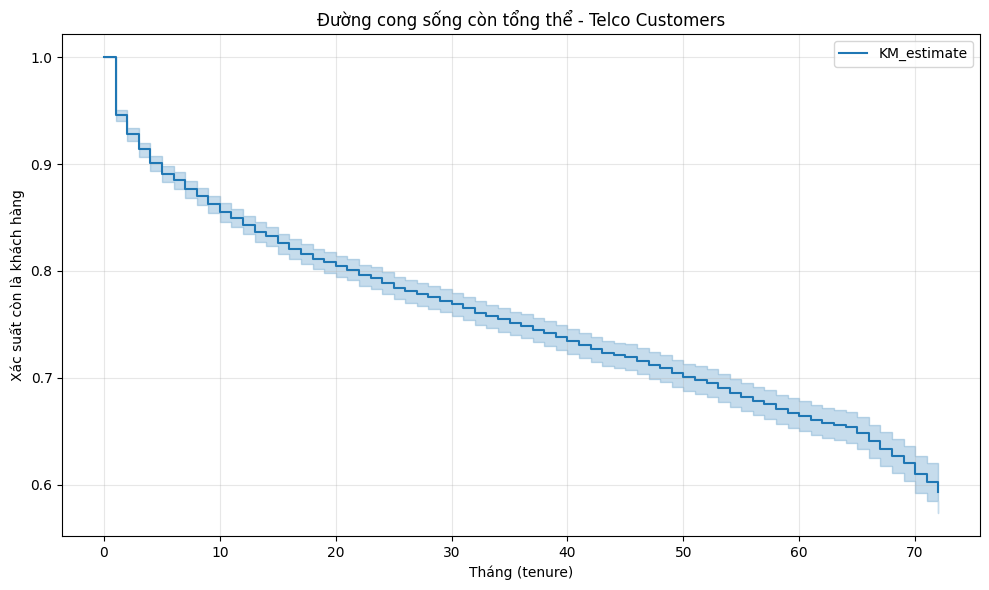


Median survival time: inf tháng
Tổng KH: 7032, Churn: 1869 (26.6%)


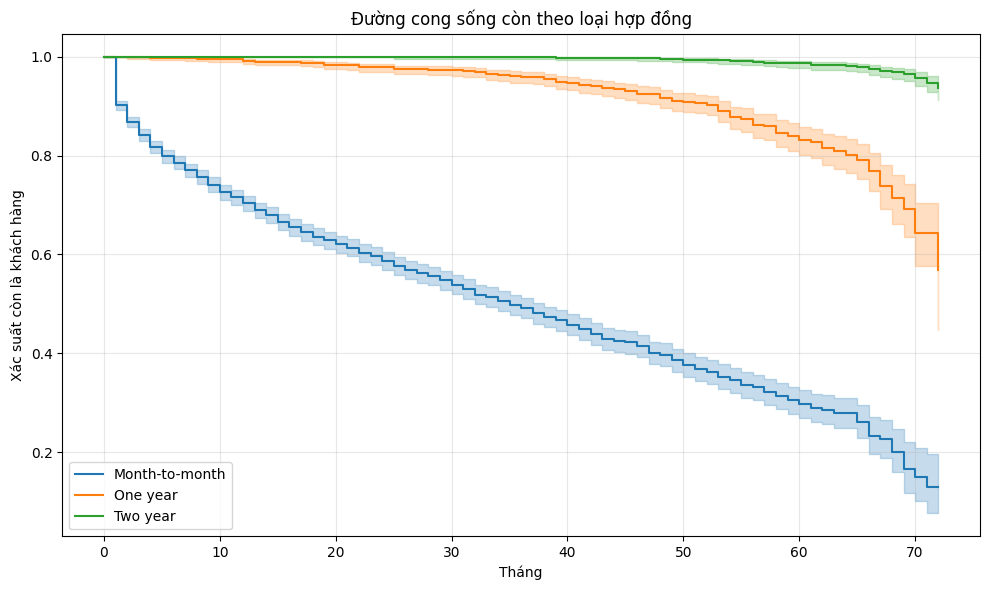


Log-rank test (Month-to-month vs One year):
  p-value = 0.000000
  → Khác biệt có ý nghĩa thống kê


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Load data
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ── Kiểm tra cấu trúc ──
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

# ── Chuẩn hóa biến target ──
df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# ── Kaplan-Meier tổng thể ──
kmf = KaplanMeierFitter()
kmf.fit(durations=df['tenure'], event_observed=df['Churn_flag'])

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Đường cong sống còn tổng thể - Telco Customers')
plt.xlabel('Tháng (tenure)')
plt.ylabel('Xác suất còn là khách hàng')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/km_overall.png', dpi=150)
plt.show()

print(f"\nMedian survival time: {kmf.median_survival_time_} tháng")
print(f"Tổng KH: {len(df)}, Churn: {df['Churn_flag'].sum()} ({df['Churn_flag'].mean():.1%})")

# ── So sánh theo loại hợp đồng (đây là chỗ thú vị) ──
fig, ax = plt.subplots(figsize=(10, 6))

for contract_type in df['Contract'].unique():
    mask = df['Contract'] == contract_type
    kmf_group = KaplanMeierFitter()
    kmf_group.fit(
        durations=df.loc[mask, 'tenure'],
        event_observed=df.loc[mask, 'Churn_flag'],
        label=contract_type
    )
    kmf_group.plot_survival_function(ax=ax)

plt.title('Đường cong sống còn theo loại hợp đồng')
plt.xlabel('Tháng')
plt.ylabel('Xác suất còn là khách hàng')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/km_by_contract.png', dpi=150)
plt.show()

# ── Log-rank test: kiểm định xem sự khác biệt có ý nghĩa thống kê không ──
month2month = df[df['Contract'] == 'Month-to-month']
one_year    = df[df['Contract'] == 'One year']
two_year    = df[df['Contract'] == 'Two year']

result = logrank_test(
    month2month['tenure'], one_year['tenure'],
    event_observed_A=month2month['Churn_flag'],
    event_observed_B=one_year['Churn_flag']
)
print(f"\nLog-rank test (Month-to-month vs One year):")
print(f"  p-value = {result.p_value:.6f}")
print(f"  → {'Khác biệt có ý nghĩa thống kê' if result.p_value < 0.05 else 'Không có ý nghĩa'}")